In [24]:
import pandas as pd
import numpy as np
import tenseal as ts
import pickle
import random
import matplotlib.pyplot as plt

# Load Compressed Embeddings

In [25]:
df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv"
)

print(df.shape)

df.head()

(14446, 129)


,Image,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,S5000L01.jpg,3.737296,0.673450,0.056452,0.184134,-0.053056,-0.677000,0.585495,-0.260572,-1.047801,...,0.077131,-0.020940,0.142039,-0.762602,-0.168722,0.041406,-0.398751,-0.083328,0.244013,0.100842
1,S5000L02.jpg,-1.532914,0.756785,0.850309,0.411241,1.219522,-0.597589,0.299023,0.266456,-0.990097,...,-0.232056,0.191040,0.007581,-0.229094,-0.210753,0.001012,0.079141,-0.041610,-0.143878,0.187849
2,S5000L04.jpg,-7.827474,-2.796364,0.439108,1.178336,1.665791,-1.602999,-1.164765,1.155259,0.360561,...,0.168901,0.381731,-0.121816,0.024067,-0.045548,-0.153538,-0.177349,-0.297411,-0.029514,0.005127
3,S5000L05.jpg,-0.172677,1.573638,-0.662676,1.244697,1.707050,-0.323209,-0.534795,-1.780205,0.522077,...,0.180868,-0.202145,0.122265,-0.299179,0.391831,0.031457,-0.514450,0.020493,0.346794,0.110880
4,S5000L08.jpg,0.272627,1.821281,0.401272,2.677169,1.050010,-0.718825,-1.095527,-2.068314,1.696303,...,-0.163445,-0.061851,0.021074,-0.272865,-0.002882,0.170077,-0.074081,-0.020336,0.272160,-0.230679


# Extract Person Labels

In [26]:
df["Label"] = df["Image"].str.extract(
    r"(S\d+)"
)

print(
    df["Label"].nunique()
)

df[["Image","Label"]].head()

1000


C:\Users\kumar\AppData\Local\Temp\ipykernel_15608\2295255266.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Label"] = df["Image"].str.extract(


,Image,Label
0,S5000L01.jpg,S5000
1,S5000L02.jpg,S5000
2,S5000L04.jpg,S5000
3,S5000L05.jpg,S5000
4,S5000L08.jpg,S5000


# Generate Genuine and Impostor Pairs

In [27]:
feature_columns = [
    col for col in df.columns
    if col not in ["Image", "Label"]
]

print(
    "Number of Features:",
    len(feature_columns)
)

Number of Features: 128


In [28]:
genuine_pairs = []

for person in df["Label"].unique():

    person_samples = df[
        df["Label"] == person
    ]

    person_samples = person_samples.reset_index(
        drop=True
    )

    if len(person_samples) >= 2:

        genuine_pairs.append(
            (
                person_samples.iloc[0],
                person_samples.iloc[1]
            )
        )

print(
    "Genuine Pairs:",
    len(genuine_pairs)
)

Genuine Pairs: 1000


In [29]:
impostor_pairs = []

persons = df["Label"].unique()

for i in range(len(persons)-1):

    person1 = df[
        df["Label"] == persons[i]
    ].iloc[0]

    person2 = df[
        df["Label"] == persons[i+1]
    ].iloc[0]

    impostor_pairs.append(
        (
            person1,
            person2
        )
    )

print(
    "Impostor Pairs:",
    len(impostor_pairs)
)

Impostor Pairs: 999


# Load CKKS Encryption Context

In [30]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60,40,40,60]
)

context.global_scale = 2**40

context.generate_galois_keys()

context.generate_relin_keys()

print(
    "CKKS Context Loaded"
)

CKKS Context Loaded


# Encrypted Cosine Similarity Function

In [31]:
def encrypted_cosine_similarity(vec1, vec2):

    encrypted_vec1 = ts.ckks_vector(
        context,
        vec1.tolist()
    )

    encrypted_vec2 = ts.ckks_vector(
        context,
        vec2.tolist()
    )

    dot_product = (
        encrypted_vec1.dot(encrypted_vec2)
    )

    similarity = dot_product.decrypt()[0]

    return similarity

# Compute Genuine Matching Scores

In [32]:
genuine_scores = []

for row1, row2 in genuine_pairs:

    vec1 = row1[feature_columns].values.astype(
        np.float64
    )

    vec2 = row2[feature_columns].values.astype(
        np.float64
    )

    score = encrypted_cosine_similarity(
        vec1,
        vec2
    )

    genuine_scores.append(score)

print(
    "Genuine Scores Generated:",
    len(genuine_scores)
)

Genuine Scores Generated: 1000


# Compute Impostor Matching Scores

In [33]:
impostor_scores = []

for row1, row2 in impostor_pairs:

    vec1 = row1[feature_columns].values.astype(
        np.float64
    )

    vec2 = row2[feature_columns].values.astype(
        np.float64
    )

    score = encrypted_cosine_similarity(
        vec1,
        vec2
    )

    impostor_scores.append(score)

print(
    "Impostor Scores Generated:",
    len(impostor_scores)
)

Impostor Scores Generated: 999


# Analyze Similarity Scores

In [34]:
print(
    "Average Genuine Score:",
    np.mean(genuine_scores)
)

print(
    "Average Impostor Score:",
    np.mean(impostor_scores)
)

Average Genuine Score: 21.841945001108282
Average Impostor Score: 1.3067546933922989


# Authentication Threshold Selection

In [35]:
threshold = (
    np.mean(genuine_scores)
    +
    np.mean(impostor_scores)
) / 2

print(
    "Threshold:",
    threshold
)

Threshold: 11.574349847250291


# Authentication Decision

In [36]:
authentication_results = []

for score in genuine_scores:

    result = (
        "MATCH"
        if score >= threshold
        else "NO_MATCH"
    )

    authentication_results.append(
        [score, result, "Genuine"]
    )

for score in impostor_scores:

    result = (
        "MATCH"
        if score >= threshold
        else "NO_MATCH"
    )

    authentication_results.append(
        [score, result, "Impostor"]
    )

In [37]:
results_df = pd.DataFrame(
    authentication_results,
    columns=[
        "Score",
        "Decision",
        "Actual_Class"
    ]
)

results_df.head()

,Score,Decision,Actual_Class
0,-6.824736,NO_MATCH,Genuine
1,-0.347095,NO_MATCH,Genuine
2,15.392568,MATCH,Genuine
3,39.692203,MATCH,Genuine
4,32.983017,MATCH,Genuine


In [38]:
results_df.to_csv(
    "../Outputs/Notebook_07/authentication_results.csv",
    index=False
)

print(
    "Authentication Results Saved"
)

Authentication Results Saved


In [39]:
matching_scores_df = pd.DataFrame({
    "Genuine_Score": genuine_scores
})

matching_scores_df.to_csv(
    "../Outputs/Notebook_07/matching_scores.csv",
    index=False
)

print(
    "Matching Scores Saved"
)

Matching Scores Saved


# Similarity Distribution Analysis

In [41]:
all_scores_df = pd.DataFrame({
    "Genuine_Score": pd.Series(genuine_scores),
    "Impostor_Score": pd.Series(impostor_scores)
})

all_scores_df.to_csv(
    "../Outputs/Notebook_07/similarity_scores.csv",
    index=False
)

print("Similarity Scores Saved")

Similarity Scores Saved


# Plot Similarity Distributions

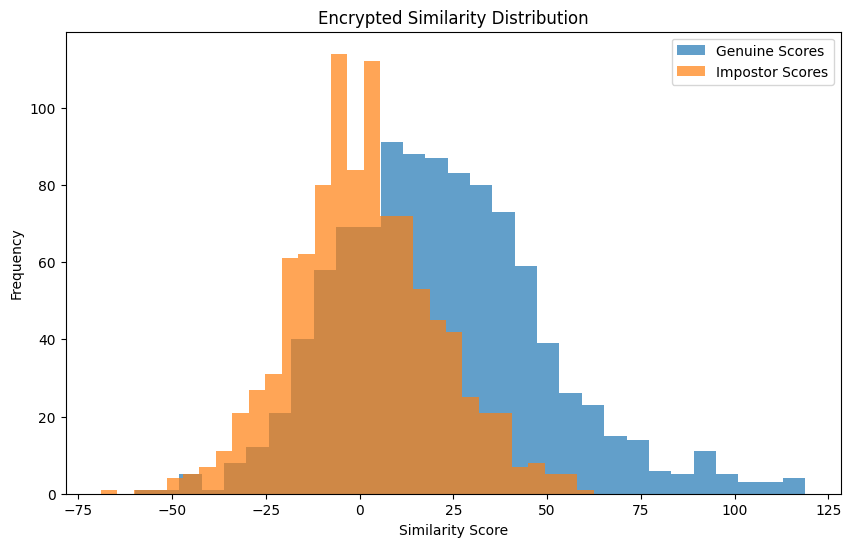

In [42]:
plt.figure(figsize=(10,6))

plt.hist(
    genuine_scores,
    bins=30,
    alpha=0.7,
    label="Genuine Scores"
)

plt.hist(
    impostor_scores,
    bins=30,
    alpha=0.7,
    label="Impostor Scores"
)

plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Encrypted Similarity Distribution")

plt.legend()

plt.savefig(
    "../Outputs/Notebook_07/similarity_distribution.png",
    bbox_inches="tight"
)

plt.show()

# Authentication Performance

In [43]:
genuine_correct = sum(
    score >= threshold
    for score in genuine_scores
)

impostor_correct = sum(
    score < threshold
    for score in impostor_scores
)

total_correct = (
    genuine_correct +
    impostor_correct
)

total_samples = (
    len(genuine_scores) +
    len(impostor_scores)
)

accuracy = (
    total_correct /
    total_samples
) * 100

print("Genuine Correct:", genuine_correct)
print("Impostor Correct:", impostor_correct)
print("Authentication Accuracy:", accuracy)

Genuine Correct: 624
Impostor Correct: 723
Authentication Accuracy: 67.38369184592297


# Results

In [44]:
print("Average Genuine Score:",
      np.mean(genuine_scores))

print("Average Impostor Score:",
      np.mean(impostor_scores))

print("Threshold:",
      threshold)

print("Authentication Accuracy:",
      accuracy)

Average Genuine Score: 21.841945001108282
Average Impostor Score: 1.3067546933922989
Threshold: 11.574349847250291
Authentication Accuracy: 67.38369184592297
